In [ ]:
import kagglehub, pandas as pd, os, seaborn as sns, matplotlib.pyplot as plt

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")

# filtrar entregados
orders = orders[orders["order_status"] == "delivered"]

# fechas
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

# joins base
df = orders.merge(order_items, on="order_id") \
           .merge(products, on="product_id") \
           .merge(reviews, on="order_id")


Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


Distribucion de reviews

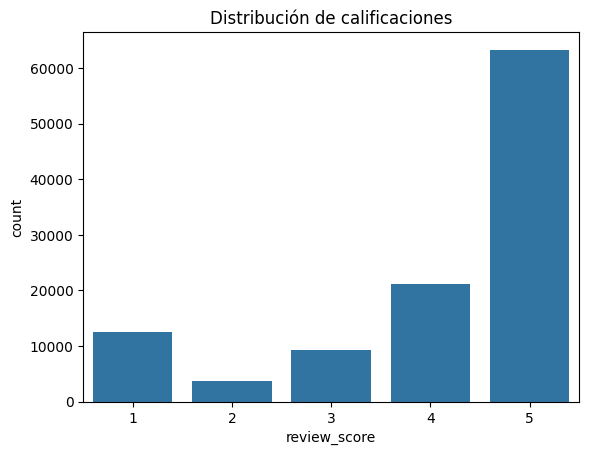

In [ ]:
sns.countplot(data=df, x="review_score")
plt.title("Distribución de calificaciones")
plt.show()


top 10 categorias

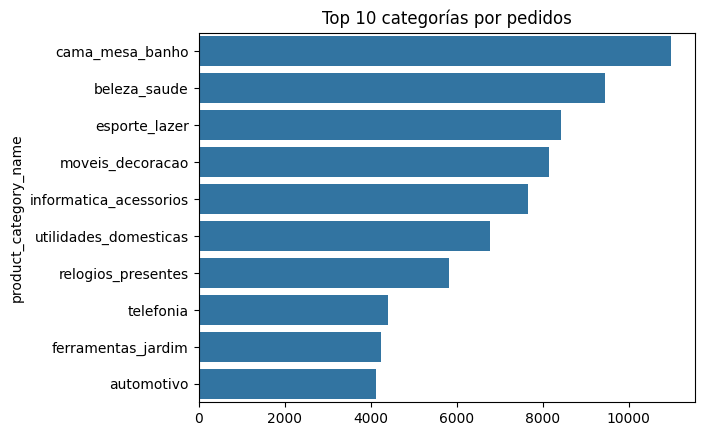

In [ ]:
top_cat = df["product_category_name"].value_counts().head(10)

sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top 10 categorías por pedidos")
plt.show()


tiempo de entrega vs calificacion

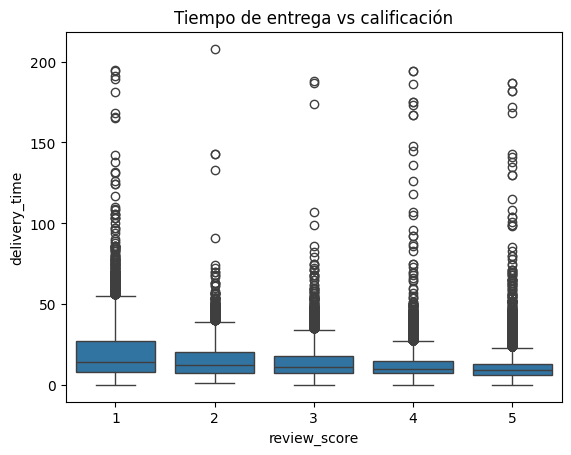

In [ ]:
df["delivery_time"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days

sns.boxplot(data=df, x="review_score", y="delivery_time")
plt.title("Tiempo de entrega vs calificación")
plt.show()


Costo de envio por categoria

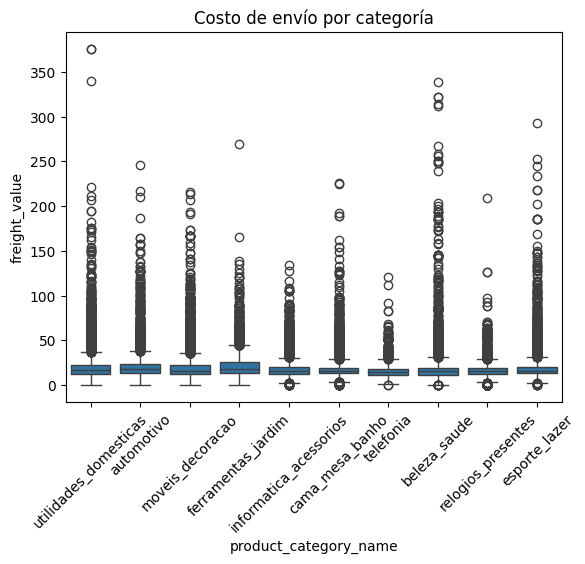

In [ ]:
top_categories = df["product_category_name"].value_counts().head(10).index
df_top = df[df["product_category_name"].isin(top_categories)]

sns.boxplot(data=df_top, x="product_category_name", y="freight_value")
plt.xticks(rotation=45)
plt.title("Costo de envío por categoría")
plt.show()


Entregas a tiempo vs retrasos

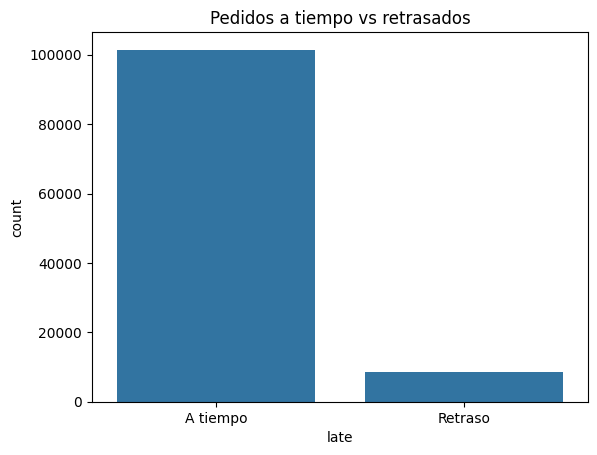

In [ ]:
df["late"] = df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]

sns.countplot(x=df["late"])
plt.title("Pedidos a tiempo vs retrasados")
plt.xticks([0,1], ["A tiempo", "Retraso"])
plt.show()
